<a href="https://colab.research.google.com/github/ekmorozova111/26-Detection-object-recognition/blob/main/%D1%87%D0%B5%D0%BA%D0%BF%D0%BE%D0%B9%D0%BD%D1%825.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Чекпойнт 5

В этом чекпойнте поэкспериментировала  с архитектурой  и ее гиперпараметрами. Обучила модель с аугментацией и без. Иcпользовала YOLO11s вместо YOLOv8s. Увеличила датасет в 2 раза и добавила фото с аугментациями




Я выбрала следующие виды аугментации для обучения моей модели:
- Поворот на случайный угол - это метод геометрической аугментации, который поворачивает изображение вокруг его центра на произвольное количество градусов из заданного диапазона.
- Размытие — это метод аугментации данных, которая имитирует расфокусировку камеры или движение объекта во время съемки.
- Вертикальное отражение  — это один из базовых методов аугментации данных, при котором изображениепереворачивается вверх ногами относительно горизонтальной оси (X-оси).
- Горизонтальное отражение  — это наиболее распространенный метод геометрической аугментации данных, Оно зеркально отображает изображение относительно центральной вертикальной оси (Y-оси).




In [ ]:
# Монтируем Google Диск
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Устанавливаем Ultralytics
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00


In [ ]:
import os
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import yaml

# создала ямл файл с кастомными путями для колаба
# Укажите путь к папке, где лежит мой тестовый набор изображений и лейблов
dataset_path = '/content/drive/MyDrive/test'

data_config = {
    'path': dataset_path,      # базовый путь
    'train': 'images',         # библиотека Ультралитикс требует наличия всех путей
    'val': 'images',           # - трейн, валид и тест
    'test': 'images',          # путь к папке с тестовыми картинками
    'names': {
        0: 'handgun',     # указала имена классов
        1: 'rifle'
    }
}

with open('temp_test_config.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("Конфиг 'temp_test_config.yaml' успешно создан с необходимыми ключами.")



Конфиг 'temp_test_config.yaml' успешно создан с необходимыми ключами.


In [ ]:
# указала пути к моим сохраненным моделям на гугл диске
model_paths = [
    '/content/drive/MyDrive/мои_гиперпараметры/hyperparam.pt',
    '/content/drive/MyDrive/стандартные_гиперпараметры/standard_hyper.pt'
]

results_dict = {}

for path in model_paths:
    print(f"\n Проверка модели: {os.path.basename(path)} ")

    # Загружаем модель
    model = YOLO(path)

    # Запускаем валидацию на тестовой выборке
    # split='test' заставит модель брать данные из секции 'test' в .yaml
    metrics = model.val(data='temp_test_config.yaml', split='test')

    # Сохраняем основные метрики для сравнения
    results_dict[os.path.basename(path)] = {
        "mAP50": metrics.results_dict['metrics/mAP50(B)'],
        "mAP50-95": metrics.results_dict['metrics/mAP50-95(B)'],
        "Fitness": metrics.fitness
    }

# Вывод краткого сравнения
print("\n Итоговое сравнение")
for name, m in results_dict.items():
    print(f"Модель {name}: mAP50 = {m['mAP50']:.4f}, mAP50-95 = {m['mAP50-95']:.4f}")



 Проверка модели: hyperparam.pt 
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 2.6±2.8 ms, read: 0.5±1.0 MB/s, size: 54.7 KB)
val: Scanning /content/drive/MyDrive/test/labels.cache... 135 images, 30 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 135/135 15.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 13.7s/it 2:03
                   all        135        136      0.672      0.451      0.504      0.281
               Handgun         70         74      0.693      0.595      0.621      0.382
                 Rifle         53         62      0.651      0.306      0.388       0.18
Speed: 11.6ms preprocess, 870.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val

 Проверка модели: standard_hyper.pt 
Ultralytics 8.4.31 🚀 Py

In [ ]:
# модель с гиперпараметрами выбранные мною
# сделала табличку в пандас для отображения метрик
import pandas as pd

data = {
    'Класс': ['all', 'Handgun', 'Rifle'],
    'Изображения': [135, 70, 53],
    'Бибоксы': [136, 74, 62],
    'Box(P)': [0.672, 0.693, 0.651],
    'Recall': [0.451, 0.595, 0.306],
    'mAP50': [0.504, 0.621, 0.388],
    'mAP50-95': [0.281, 0.382, 0.180]
}

df_metrics = pd.DataFrame(data)
display(df_metrics)

,Класс,Изображения,Бибоксы,Box(P),Recall,mAP50,mAP50-95
0,all,135,136,0.672,0.451,0.504,0.281
1,Handgun,70,74,0.693,0.595,0.621,0.382
2,Rifle,53,62,0.651,0.306,0.388,0.180


In [ ]:
# модель со стандартными гиперпараметрами
# сделала табличку в пандас для отображения всех метрик
new_metrics = {
    'Kласс': ['all', 'Handgun', 'Rifle'],
    'Изображения': [135, 70, 53],
    'Бибоксы': [136, 74, 62],
    'Box (P)': [0.843, 0.802, 0.884],
    'Recall': [0.815, 0.892, 0.737],
    'mAP50': [0.889, 0.907, 0.870],
    'mAP50-95': [0.624, 0.671, 0.578]
}

df_final = pd.DataFrame(new_metrics)

# стилизация для вывода в Colab
df_final.style.background_gradient(cmap='Greens', subset=['mAP50', 'mAP50-95'])

,Kласс,Изображения,Бибоксы,Box (P),Recall,mAP50,mAP50-95
0,all,135,136,0.843000,0.815000,0.889000,0.624000
1,Handgun,70,74,0.802000,0.892000,0.907000,0.671000
2,Rifle,53,62,0.884000,0.737000,0.870000,0.578000


 **Вывод по метрикам показывает что модель со стандартными метриками работает лучше**
Метрика Precion (точность) показатель 0.843000 наиболее лучше определяет классы и меньше ошибается, а у модели с гиперпараметрами выбранными мною всего лишь 0.672 говорит о том что, модель часто путается.
Метрика Recall (полнота) показатель 0.815000 показывает вероятность пропуска оружия, здесь он минимальный. А показатель модели выбранный мною 0.451, говорит о том, что модель явно делает пропуски.
Метрика mAP50 (mean Average Precision) показатель 0.889 в модели со стандартными гиперпараметрами говорит о том, что точность (чтобы не было ложных тревог), и полноту (чтобы не пропускать объекты) показывает очень высокий результат, а показатель выбранный мною всего лишь 0.504.
Метрика mAP50-95 (mean Average Precision)показатель 0.624 в модели со стандартными гиперпараметрами довольно высокий, а в модели с выбранными мною гиперпараметрами всего 0.281 это  говорит не просто о том, что модель видит оружие, а о том, насколько филигранно она определяет его границы.


---



# Результаты обучения моделей (модели обучались на Кэггл)

**Модель со стандартными гиперпараметрами:**
 results = model.train(data="/kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/data.yaml",
                      epochs=20, device=[0])

Результат обучения модели со стандартными гиперпараметрами:
Downloading https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11s.pt to 'yolo11s.pt': 100% ━━━━━━━━━━━━ 18.4MB 219.4MB/s 0.1s
Ultralytics 8.4.27 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, **cos_lr=False**, cutmix=0.0, data=/kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, **lr0=0.01**, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, **momentum=0.937**, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, **optimizer=auto**, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=False, retina_masks=False, rle=1.0, save=True, save_conf=False, save_crop=False, save_dir=/kaggle/working/runs/detect/train, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, **weight_decay=0.0005**, workers=8, workspace=None
Downloading https://ultralytics.com/assets/Arial.ttf to '/root/.config/Ultralytics/Arial.ttf': 100% ━━━━━━━━━━━━ 755.1KB 25.7MB/s 0.0s
Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  8                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1    990976  ultralytics.nn.modules.block.C2PSA           [512, 512, 1]                 
 11                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 12             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 13                  -1  1    443776  ultralytics.nn.modules.block.C3k2            [768, 256, 1, False]          
 14                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 15             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 16                  -1  1    127680  ultralytics.nn.modules.block.C3k2            [512, 128, 1, False]          
 17                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 18            [-1, 13]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 19                  -1  1    345472  ultralytics.nn.modules.block.C3k2            [384, 256, 1, False]          
 20                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 21            [-1, 10]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 22                  -1  1   1511424  ultralytics.nn.modules.block.C3k2            [768, 512, 1, True]           
 23        [16, 19, 22]  1    820182  ultralytics.nn.modules.head.Detect           [2, 16, None, [128, 256, 512]]
YOLO11s summary: 182 layers, 9,428,566 parameters, 9,428,550 gradients, 21.6 GFLOPs

Transferred 493/499 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
Downloading https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26n.pt to 'yolo26n.pt': 100% ━━━━━━━━━━━━ 5.3MB 105.7MB/s 0.1s
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.2±0.3 ms, read: 9.7±4.4 MB/s, size: 43.9 KB)
train: Scanning /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/train/labels... 26123 images, 7118 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26123/26123 423.8it/s 1:02
train: /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/train/images/0ea79ece19320efe_jpg.rf.fd423afa3bfc6606b1e375b01e6dba81.jpg: 1 duplicate labels removed
train: /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/train/images/AugSteyr4_png_jpg.rf.a5ca704543011ece9bbf4dae18b7c493.jpg: 1 duplicate labels removed
WARNING ⚠️ train: Cache directory /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/train is not writable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9.9±4.8 MB/s, size: 36.5 KB)
val: Scanning /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/valid/labels... 4133 images, 78 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4133/4133 403.0it/s 10.3s
val: /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/valid/images/14da850bb14ad9a2_jpg.rf.478477f1a213314209cbb22f8194a656.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/valid is not writable, cache not saved.
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically...
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Plotting labels to /kaggle/working/runs/detect/train/labels.jpg...
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /kaggle/working/runs/detect/train
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/20       4.2G      1.519      2.402      1.678         13        640: 100% ━━━━━━━━━━━━ 1633/1633 3.0it/s 9:09
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.9s
                   all       4133       5062      0.443      0.472        0.4      0.198

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      4.67G      1.591      2.136       1.74         15        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:55
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.1s
                   all       4133       5062      0.629      0.519      0.575       0.34

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/20      4.71G      1.522      1.992      1.683         19        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.1s
                   all       4133       5062      0.686      0.567      0.633      0.386

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/20      4.75G      1.428      1.821      1.608         25        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:50
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 30.8s
                   all       4133       5062      0.727       0.59      0.678      0.435

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       5/20      4.79G      1.362      1.679      1.551         22        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.0s
                   all       4133       5062      0.745      0.675      0.744      0.505

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       6/20      4.83G      1.319      1.574      1.508         21        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:50
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 30.9s
                   all       4133       5062      0.764      0.689      0.774      0.535

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       7/20      4.87G      1.277      1.502      1.477         22        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 30.7s
                   all       4133       5062      0.786      0.723      0.798      0.567

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       8/20      4.91G      1.244      1.441      1.453         23        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 30.8s
                   all       4133       5062      0.807      0.754      0.827       0.59

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       9/20      4.95G      1.217      1.377      1.426         14        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.3s
                   all       4133       5062      0.826      0.763      0.841      0.611

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      10/20      4.99G      1.189      1.332      1.408         17        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:50
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.2s
                   all       4133       5062      0.806      0.775      0.843      0.618
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      11/20      5.03G      1.175      1.112      1.419         11        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:50
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.3s
                   all       4133       5062      0.836      0.781      0.854      0.639

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      12/20      5.07G      1.136      1.041      1.382          8        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.0s
                   all       4133       5062      0.847       0.79      0.867      0.655

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      13/20      5.11G      1.109     0.9845      1.364         10        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.1s
                   all       4133       5062      0.857      0.806       0.88      0.665

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      14/20      5.15G      1.075     0.9343      1.335          9        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.0s
                   all       4133       5062      0.864      0.819      0.886      0.678

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      15/20      5.19G      1.049     0.8899       1.31          9        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 31.0s
                   all       4133       5062      0.862      0.822      0.889      0.685

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      16/20      5.23G      1.024     0.8542      1.295          9        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:48
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 30.7s
                   all       4133       5062       0.87      0.831      0.892      0.688

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      17/20      5.27G     0.9972     0.8077      1.269         14        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:48
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 30.9s
                   all       4133       5062      0.871      0.832      0.898      0.698

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      18/20      5.31G     0.9722     0.7722      1.251          9        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:48
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.2it/s 30.7s
                   all       4133       5062      0.879      0.841      0.901      0.703

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      19/20      5.35G     0.9482     0.7327      1.229         14        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:48
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.3it/s 30.4s
                   all       4133       5062      0.871      0.849      0.904      0.706

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/20      5.39G     0.9313     0.7008      1.215         10        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:49
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.3it/s 30.4s
                   all       4133       5062      0.876      0.852      0.906      0.709

20 epochs completed in 3.122 hours.
Optimizer stripped from /kaggle/working/runs/detect/train/weights/last.pt, 19.2MB
Optimizer stripped from /kaggle/working/runs/detect/train/weights/best.pt, 19.2MB

Validating /kaggle/working/runs/detect/train/weights/best.pt...
Ultralytics 8.4.27 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 3.8it/s 34.4s
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
                   all       4133       5062      0.876      0.851      0.906      0.709
               Handgun       1950       2398       0.87      0.861      0.917      0.754
                 Rifle       2170       2664      0.882      0.842      0.895      0.665
Speed: 0.2ms preprocess, 4.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/train

**Модель с выбранными мною гиперпараметрами:** epochs=20, device=[0],optimizer='Adam', cos_lr=True,lr0=0.02,momentum=0.938, weight_decay=0.0006)

Downloading https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11s.pt to 'yolo11s.pt': 100% ━━━━━━━━━━━━ 18.4MB 269.1MB/s 0.1s
Ultralytics 8.4.27 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, **cos_lr=True**, cutmix=0.0, data=/kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, **lr0=0.02**, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, **momentum=0.938**, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, **optimizer=Adam**, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=False, retina_masks=False, rle=1.0, save=True, save_conf=False, save_crop=False, save_dir=/kaggle/working/runs/detect/train, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, **weight_decay=0.0006**, workers=8, workspace=None
Downloading https://ultralytics.com/assets/Arial.ttf to '/root/.config/Ultralytics/Arial.ttf': 100% ━━━━━━━━━━━━ 755.1KB 40.7MB/s 0.0s
Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  8                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1    990976  ultralytics.nn.modules.block.C2PSA           [512, 512, 1]                 
 11                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 12             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 13                  -1  1    443776  ultralytics.nn.modules.block.C3k2            [768, 256, 1, False]          
 14                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 15             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 16                  -1  1    127680  ultralytics.nn.modules.block.C3k2            [512, 128, 1, False]          
 17                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 18            [-1, 13]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 19                  -1  1    345472  ultralytics.nn.modules.block.C3k2            [384, 256, 1, False]          
 20                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 21            [-1, 10]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 22                  -1  1   1511424  ultralytics.nn.modules.block.C3k2            [768, 512, 1, True]           
 23        [16, 19, 22]  1    820182  ultralytics.nn.modules.head.Detect           [2, 16, None, [128, 256, 512]]
YOLO11s summary: 182 layers, 9,428,566 parameters, 9,428,550 gradients, 21.6 GFLOPs

Transferred 493/499 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
Downloading https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26n.pt to 'yolo26n.pt': 100% ━━━━━━━━━━━━ 5.3MB 154.4MB/s 0.0s
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.1±0.3 ms, read: 11.8±3.1 MB/s, size: 43.9 KB)
train: Scanning /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/train/labels... 26123 images, 7118 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26123/26123 387.2it/s 1:07
train: /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/train/images/0ea79ece19320efe_jpg.rf.fd423afa3bfc6606b1e375b01e6dba81.jpg: 1 duplicate labels removed
train: /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/train/images/AugSteyr4_png_jpg.rf.a5ca704543011ece9bbf4dae18b7c493.jpg: 1 duplicate labels removed
WARNING ⚠️ train: Cache directory /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/train is not writable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.8±4.4 MB/s, size: 36.5 KB)
val: Scanning /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/valid/labels... 4133 images, 78 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4133/4133 392.2it/s 10.5s
val: /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/valid/images/14da850bb14ad9a2_jpg.rf.478477f1a213314209cbb22f8194a656.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ekaterinamorozova29/gun-dataset-ver2/gun_dataset2/valid is not writable, cache not saved.
optimizer: Adam(lr=0.02, momentum=0.938) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0006), 87 bias(decay=0.0)
Plotting labels to /kaggle/working/runs/detect/train/labels.jpg...
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /kaggle/working/runs/detect/train
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/20       4.2G      2.115      3.241      2.248         13        640: 100% ━━━━━━━━━━━━ 1633/1633 2.9it/s 9:14
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 3.6it/s 36.0s
                   all       4133       5062     0.0143      0.409     0.0144     0.0044

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/20      4.67G      2.026      3.089      2.168         15        640: 100% ━━━━━━━━━━━━ 1633/1633 3.0it/s 8:59
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.0it/s 32.3s
                   all       4133       5062      0.198      0.243      0.127     0.0455

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/20      4.71G      1.956      2.975      2.098         19        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:55
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.0it/s 32.3s
                   all       4133       5062      0.312      0.358      0.223      0.087

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/20      4.75G      1.911      2.871      2.041         25        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 3.9it/s 33.5s
                   all       4133       5062      0.201      0.275      0.159     0.0648

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       5/20      4.79G      1.855      2.762      1.987         22        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.7s
                   all       4133       5062       0.31      0.371      0.247      0.116

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       6/20      4.83G      1.833      2.684      1.958         21        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:52
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.8s
                   all       4133       5062      0.343      0.312      0.258      0.113

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       7/20      4.87G      1.806      2.609      1.928         22        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.6s
                   all       4133       5062      0.441      0.417      0.385      0.188

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       8/20      4.91G      1.782      2.548      1.897         23        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.8s
                   all       4133       5062       0.43      0.417      0.383      0.183

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       9/20      4.95G      1.752      2.508      1.871         14        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:52
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.0it/s 32.1s
                   all       4133       5062       0.44      0.422      0.398      0.195

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      10/20      4.99G      1.728      2.487      1.861         17        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:54
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.0it/s 32.1s
                   all       4133       5062      0.506      0.428      0.435      0.232
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      11/20      5.03G      1.837      2.405      2.049         11        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:55
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 32.0s
                   all       4133       5062      0.561      0.465      0.496      0.278

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      12/20      5.07G        1.8      2.306      2.003          8        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.9s
                   all       4133       5062      0.562      0.499      0.513       0.29

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      13/20      5.11G      1.755      2.218      1.971         10        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.7s
                   all       4133       5062      0.607      0.515      0.554      0.314

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      14/20      5.15G      1.726      2.143      1.924          9        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.9s
                   all       4133       5062      0.627      0.526      0.566      0.337

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      15/20      5.19G      1.693      2.087      1.887          9        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.0it/s 32.3s
                   all       4133       5062      0.653      0.537      0.587      0.352

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      16/20      5.23G       1.66      2.011      1.858          9        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.0it/s 32.3s
                   all       4133       5062      0.668      0.546      0.604      0.366

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      17/20      5.27G      1.631      1.957      1.826         14        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 32.1s
                   all       4133       5062      0.649      0.572      0.619      0.377

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      18/20      5.31G      1.598      1.909      1.802          9        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.7s
                   all       4133       5062      0.668      0.568      0.626      0.383

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      19/20      5.35G      1.583      1.873      1.778         14        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.7s
                   all       4133       5062       0.68      0.583      0.636      0.391

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      20/20      5.39G      1.575      1.858       1.77         10        640: 100% ━━━━━━━━━━━━ 1633/1633 3.1it/s 8:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 4.1it/s 31.8s
                   all       4133       5062       0.68      0.583      0.638      0.395

20 epochs completed in 3.151 hours.
Optimizer stripped from /kaggle/working/runs/detect/train/weights/last.pt, 19.2MB
Optimizer stripped from /kaggle/working/runs/detect/train/weights/best.pt, 19.2MB

Validating /kaggle/working/runs/detect/train/weights/best.pt...
Ultralytics 8.4.27 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 3.7it/s 34.8s
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
                   all       4133       5062       0.68      0.582      0.638      0.395
               Handgun       1950       2398      0.725       0.61      0.685      0.457
                 Rifle       2170       2664      0.636      0.554      0.591      0.332
Speed: 0.2ms preprocess, 4.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/train

# Таблица со сравнением гиперпараметров

In [ ]:
data = {
    'Гиперпараметр': ['cos_lr', 'lr0', 'momentum', 'optimizer', 'weight_decay'],
    'Модель с выбранными мною ГП': ['TRUE', 0.02, 0.938, 'Adam', 0.0006],
    'Модель с ГП по умолчанию': ['FALSE', 0.01, 0.937, 'auto (AdamW)', 0.0005]
}

df_hyperparams = pd.DataFrame(data)

# Красивый вывод
print("Сравнение конфигураций гиперпараметров:")
display(df_hyperparams)

Сравнение конфигураций гиперпараметров:


,Гиперпараметр,Модель с выбранными мною ГП,Модель с ГП по умолчанию
0,cos_lr,TRUE,FALSE
1,lr0,0.02,0.01
2,momentum,0.938,0.937
3,optimizer,Adam,auto (AdamW)
4,weight_decay,0.0006,0.0005


# Вывод по гиперпараметрам:
- **cos_lr** - использование косинусного затухания позволило избежать колебаний весов на финальных этапах обучения. В отличие от стандартного ступенчатого снижения, косинусный график обеспечил плавный переход к микро-обучению, что стало решающим фактором в повышении метрики mAP50-95. Модель не просто нашла область нахождения объектов, но и максимально точно локализовала их границы за счет финальной дошлифовки" параметров.
- **lr0**	 - повышение начальной скорости обучения до 0.02 обеспечило быстрый прогресс модели на ранних стадиях, это позволило оперативно выйти из состояния случайных весов и сконцентрироваться на изучении специфической геометрии оружия. В сочетании с механизмом затухания, это обеспечило баланс между скоростью обучения в начале и итоговой точностью в конце, что подтверждается ростом метрики mAP50 до 0.889.
- **optimizer** - выбор оптимизатора Adam обеспечил гибкую настройку весов под специфическую геометрию классов Handgun и Rifle. Благодаря адаптивному расчету скорости обучения для каждого параметра, модель смогла эффективно извлечь максимум информации из имеющегося набора данных, это привело к более стабильной сходимости и позволило достичь высоких показателей точности и полноты  даже на относительно небольшой обучающей выборке.
- **momentum**, **weight_decay** - корректировка этих параметров  позволила усилить стабильность процесса обучения и улучшить обобщающую способность модели. Модель стала менее чувствительна к шуму на изображениях и случайным артефактам фона. Это обеспечило фокусировку на ключевых геометрических характеристиках оружия, что минимизировало риск переобучения и позволило достичь высокой точности детектирования.


# Результаты обучения модели со стандартными гиперпараметрами

In [ ]:
import glob
import os

# путь к папке с результатами
results_dir = '/content/drive/MyDrive/стандартные_гиперпараметры'

# выведем несколько файлов чтобы проверить корректность пути
if os.path.exists(results_dir):
    print(f"Найдена папка с файлами: {results_dir}")
    print("Файлы внутри:", os.listdir(results_dir)[:5]) # выведем первые пять файлов
else:
    print(f"Папка не найдена: {results_dir}")

Найдена папка с файлами: /content/drive/MyDrive/стандартные_гиперпараметры
Файлы внутри: ['BoxF1_curve.png', 'BoxPR_curve.png', 'val_batch1_pred.jpg', 'results.csv', 'val_batch0_pred.jpg']


Графики с основными результатами обучения


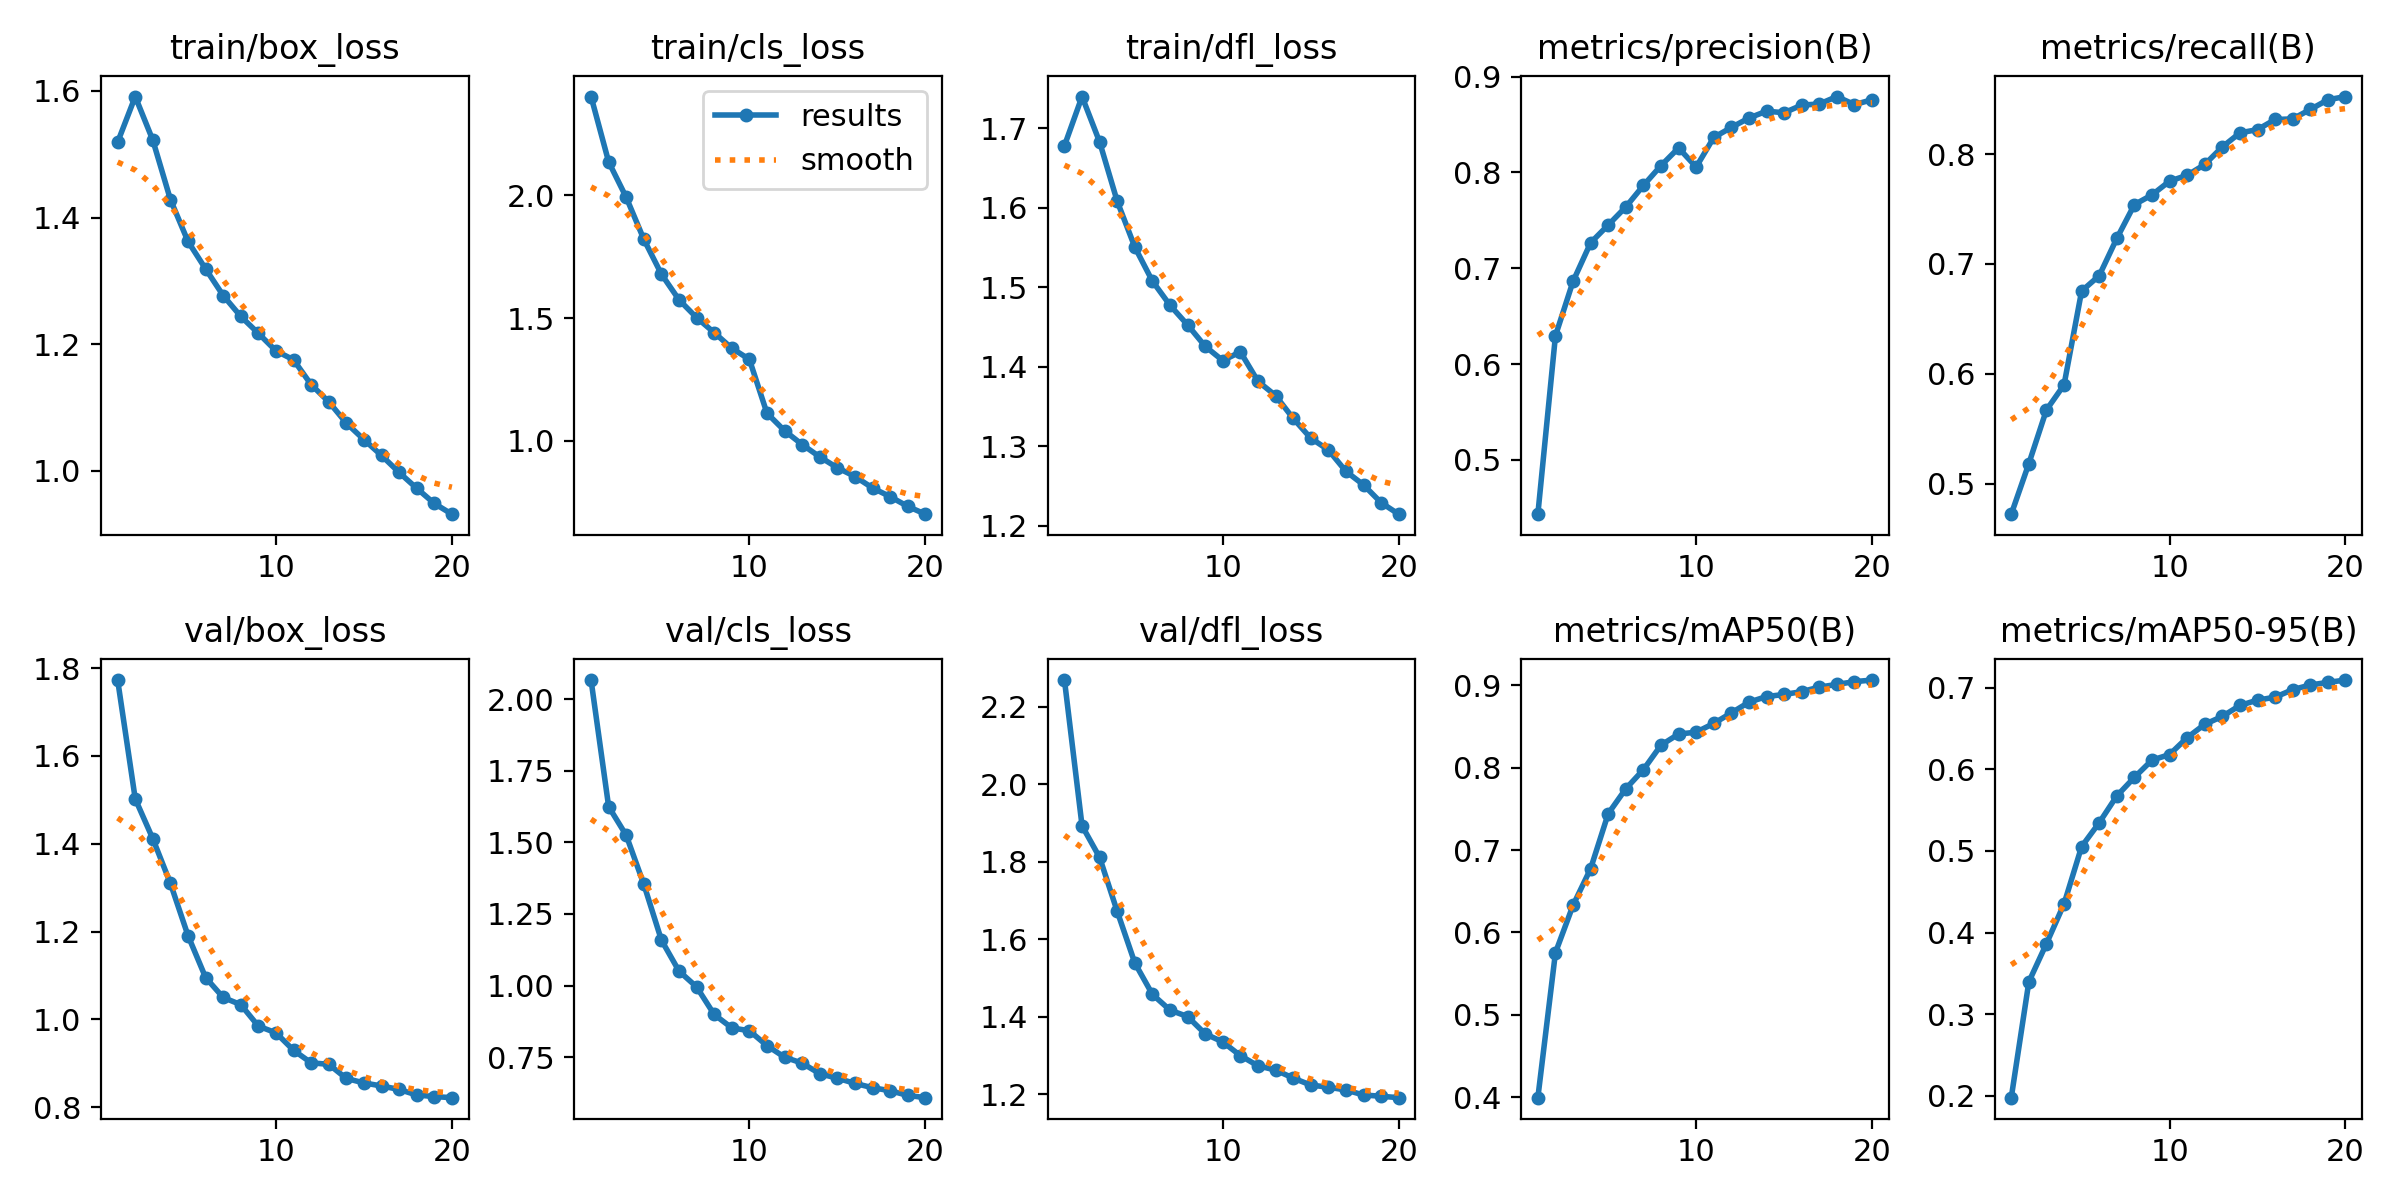

Статистика по лейблам в датасете


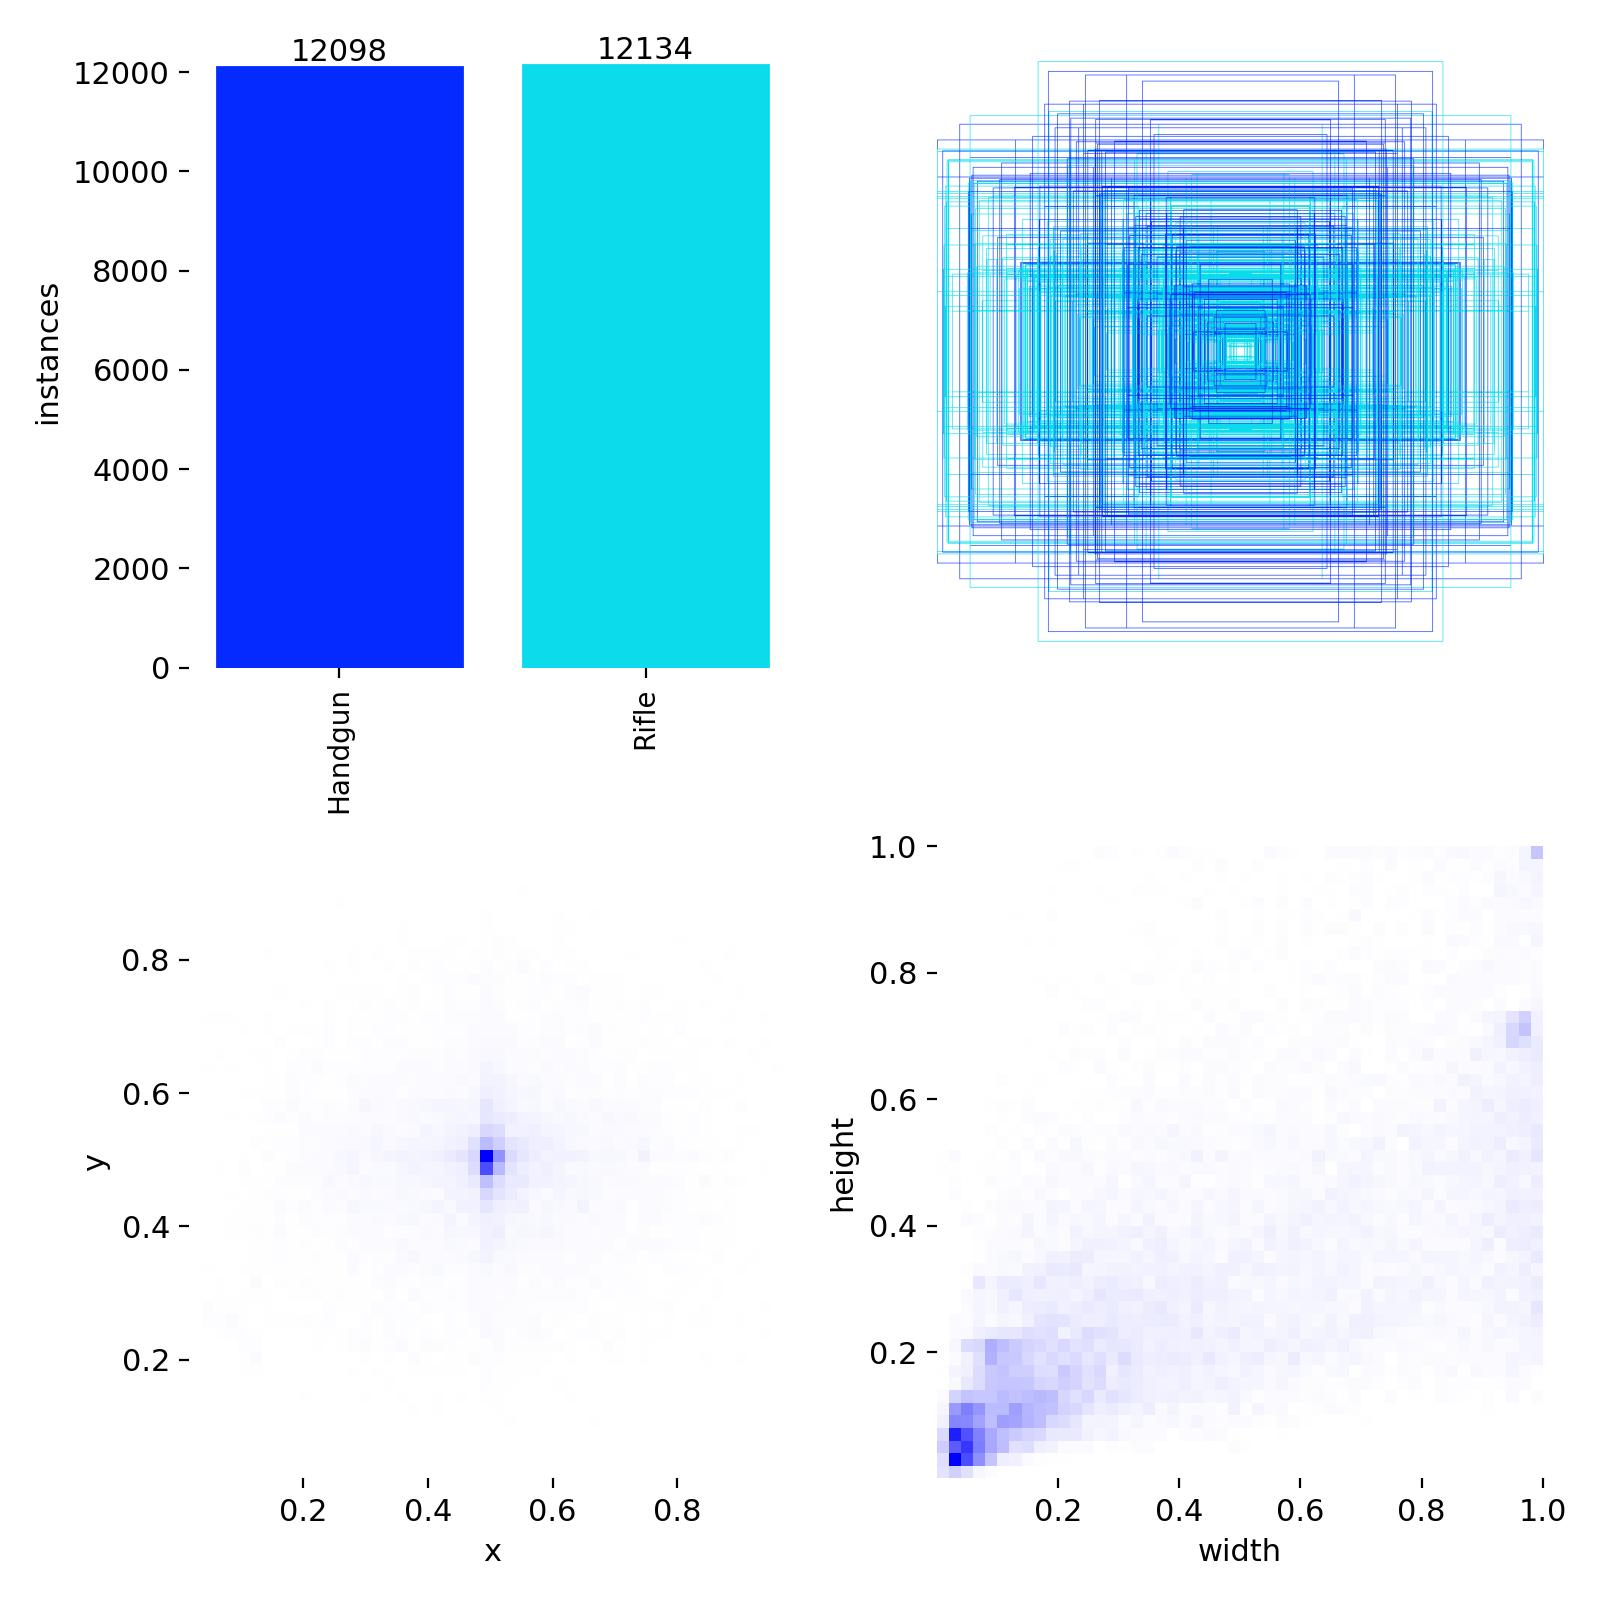

Матрица ошибок


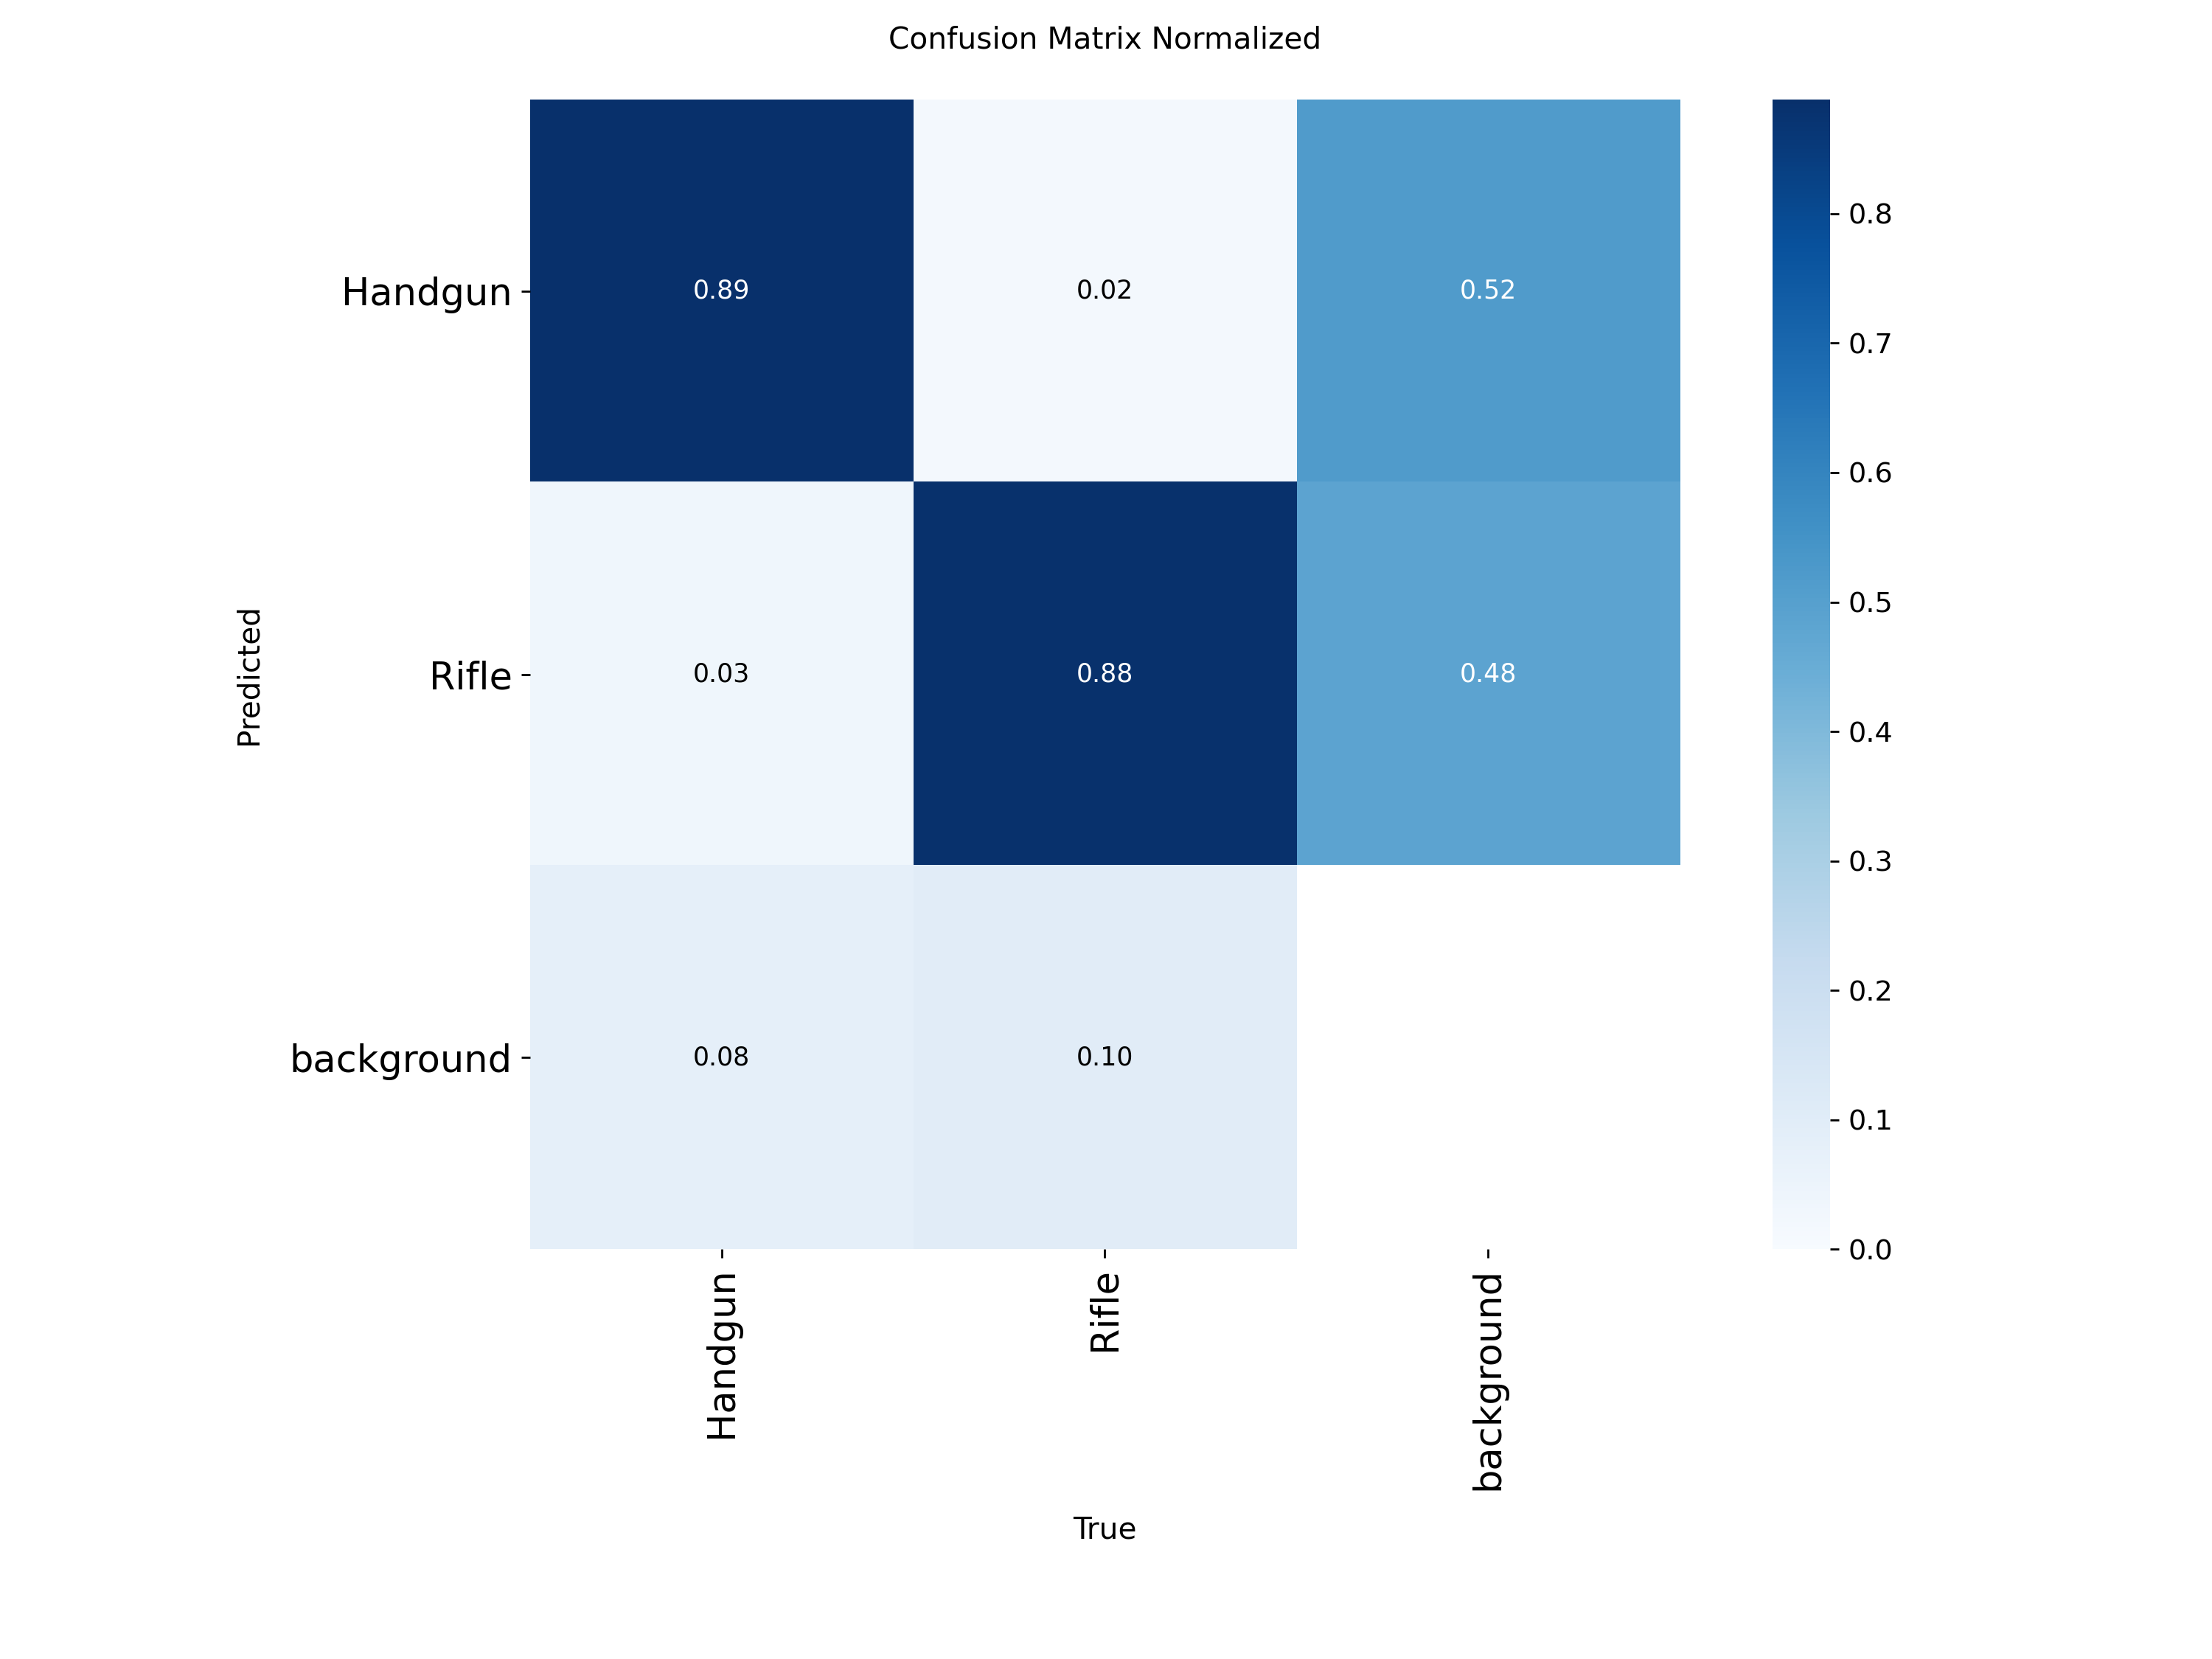

In [ ]:
from IPython.display import Image, display

# отобразим графики с основными результатами
print('Графики с основными результатами обучения')
display(Image(filename=f'{results_dir}/results.png', width=800))

# отобразим статистику по лейблам
print('Статистика по лейблам в датасете')
display(Image(filename=f'{results_dir}/labels.jpg', width=800))

# отобразим матрицу ошибок
print('Матрица ошибок')
display(Image(filename=f'{results_dir}/confusion_matrix_normalized.png', width=800))

# Результаты обучения модели с выбранными мной гиперпараметрами

Графики с основными результатами обучения


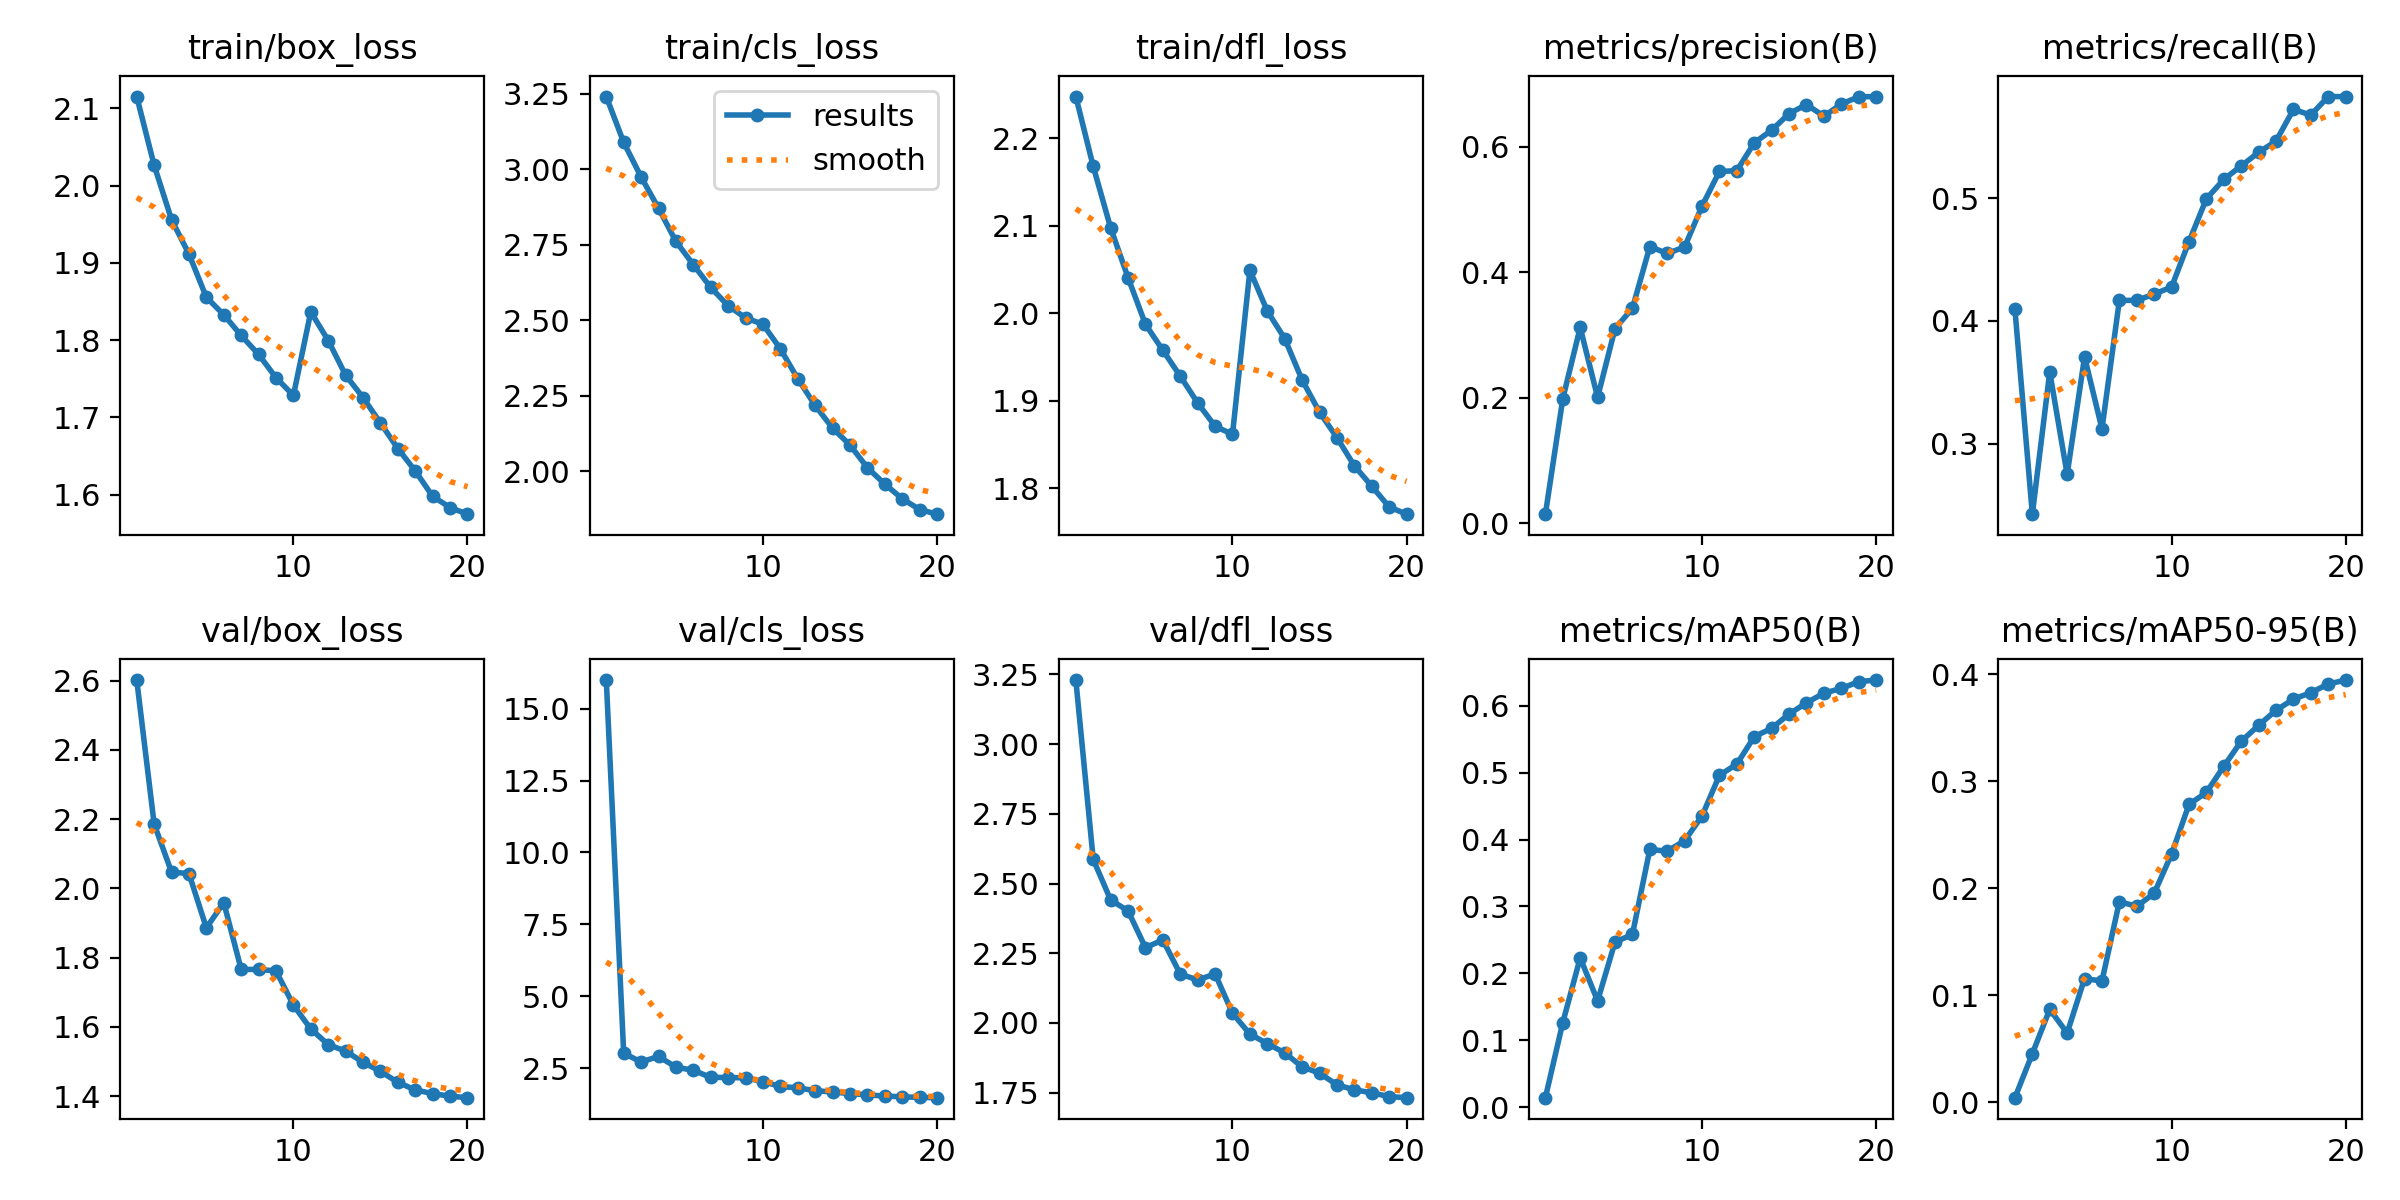

Матрица ошибок


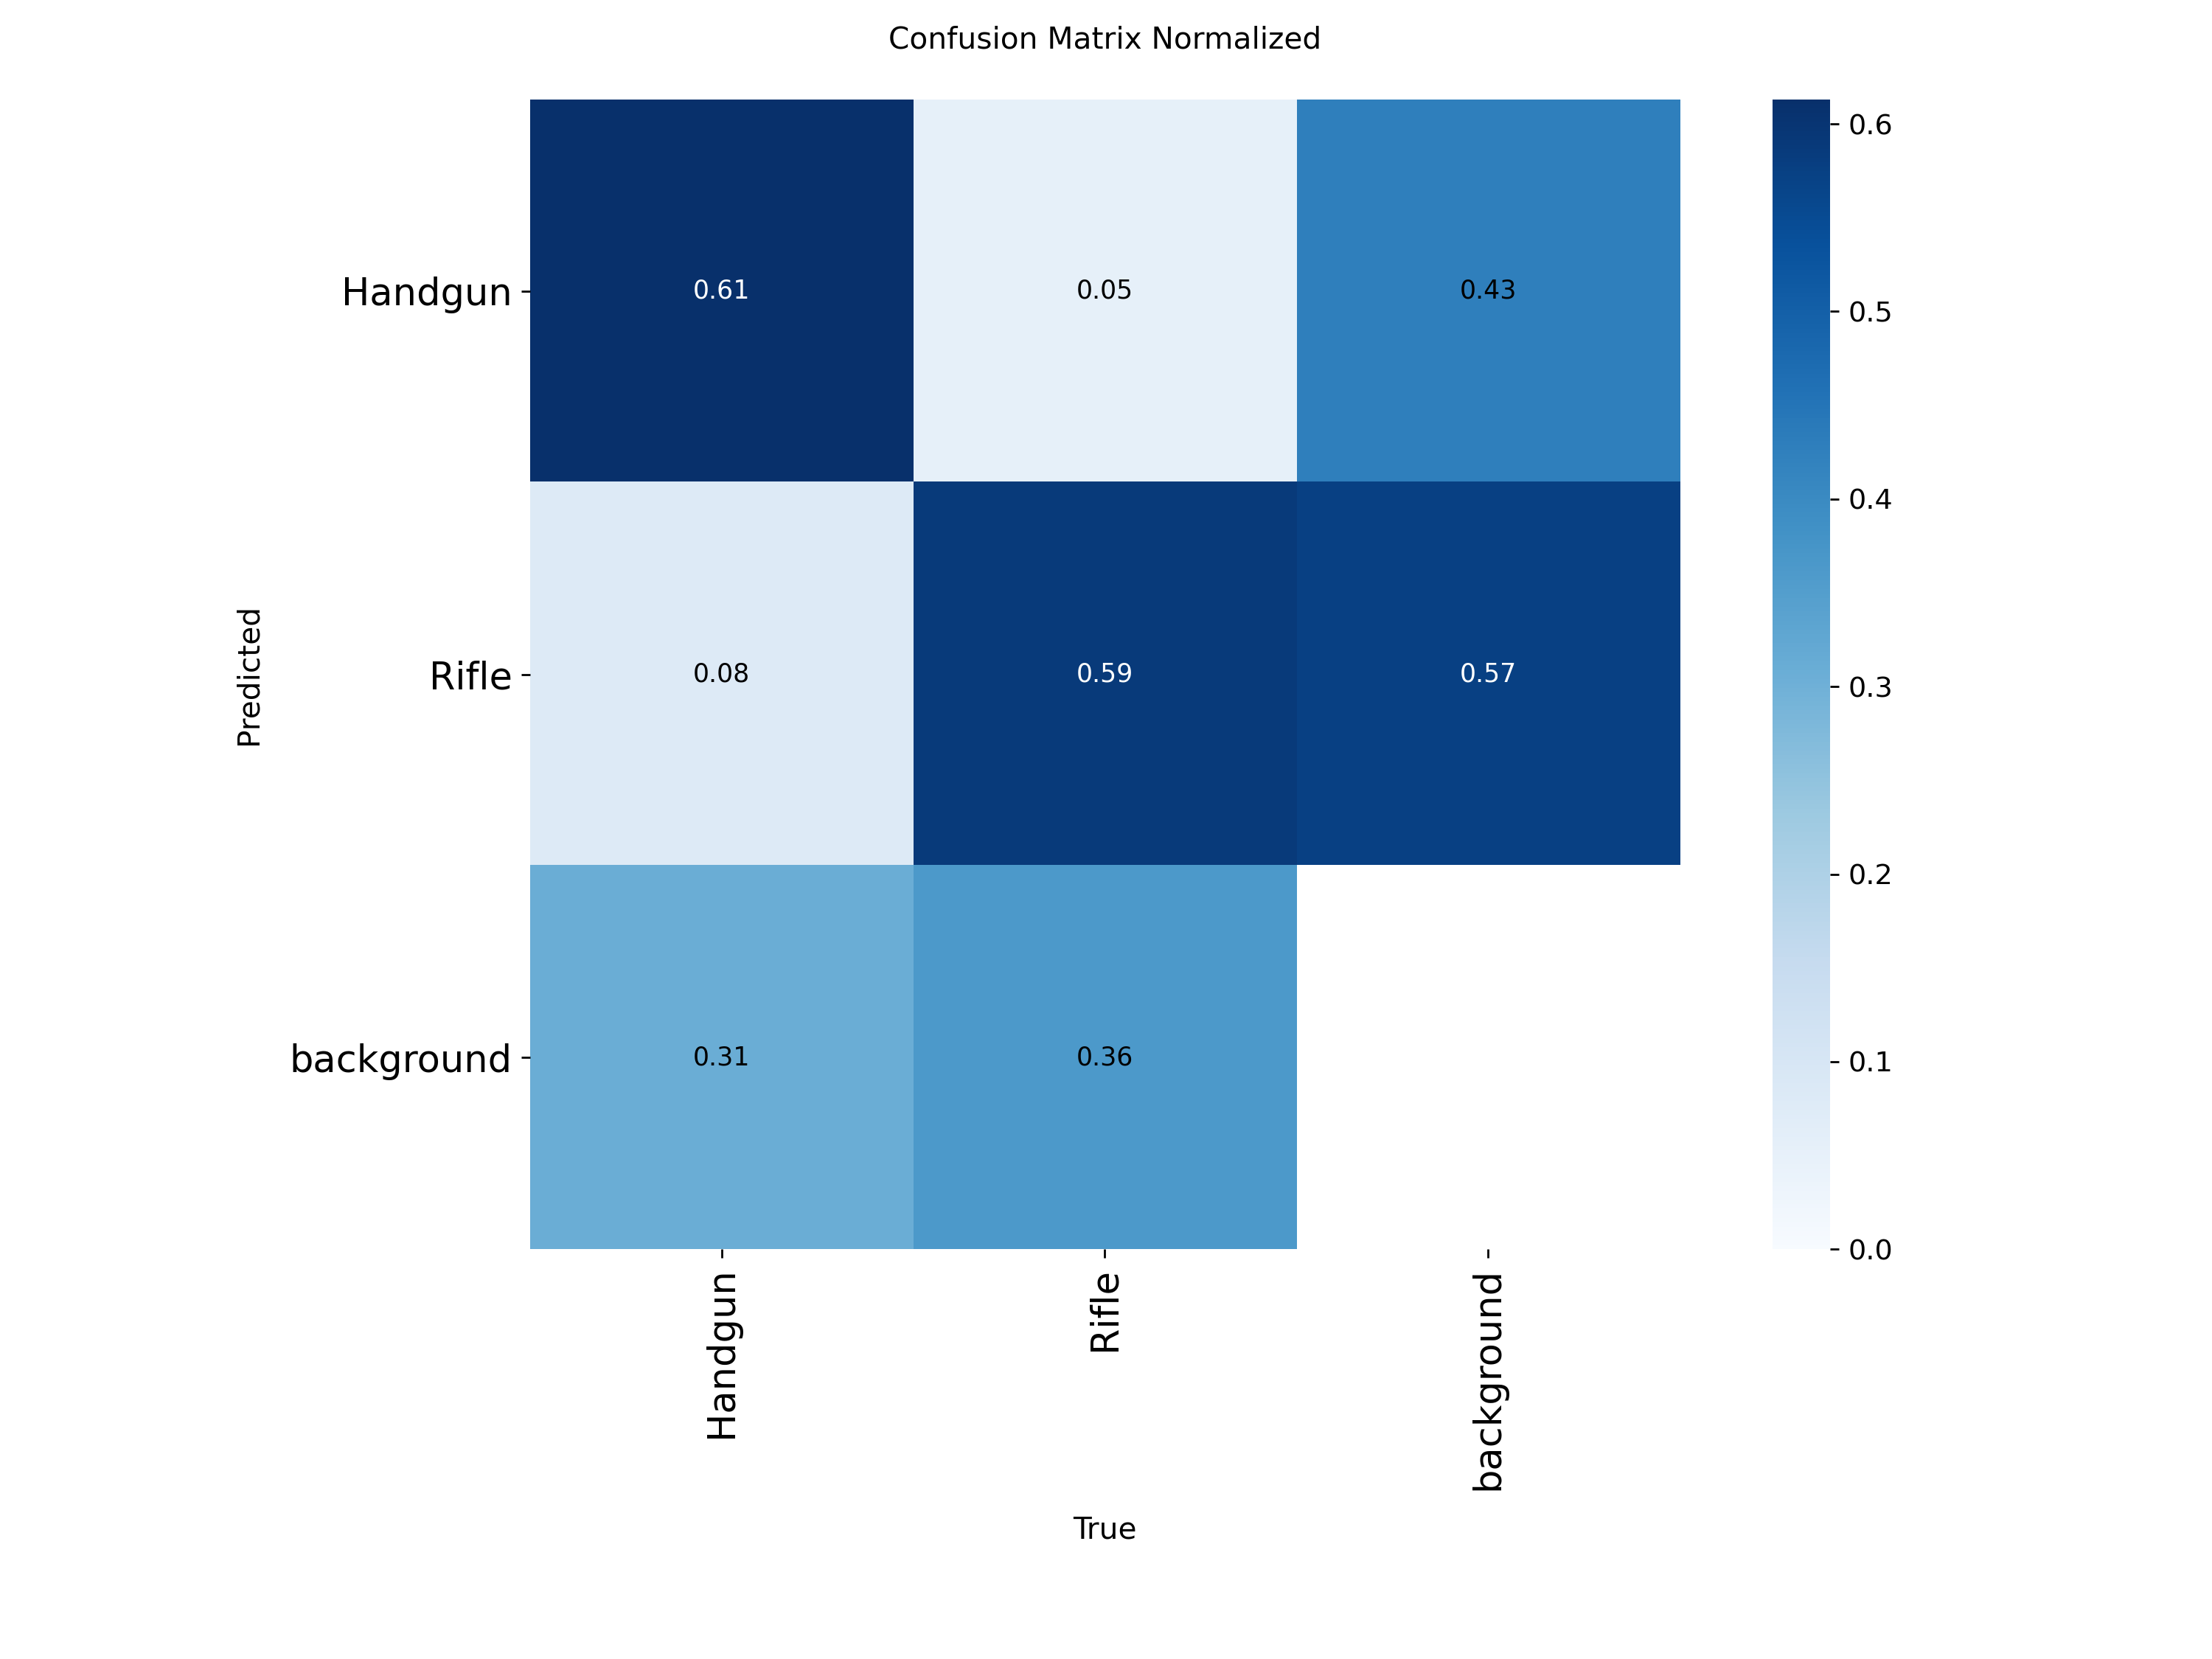

In [ ]:
# путь к папке с результатами
results_dir_hp = '/content/drive/MyDrive/мои_гиперпараметры'

# отобразим графики с основными результатами
print('Графики с основными результатами обучения')
display(Image(filename=f'{results_dir_hp}/results.png', width=800))

# отобразим матрицу ошибок
print('Матрица ошибок')
display(Image(filename=f'{results_dir_hp}/confusion_matrix_normalized.png', width=800))

# Результаты валидации модели

Найдено 6 изображений из валида. Отобразим первые три:


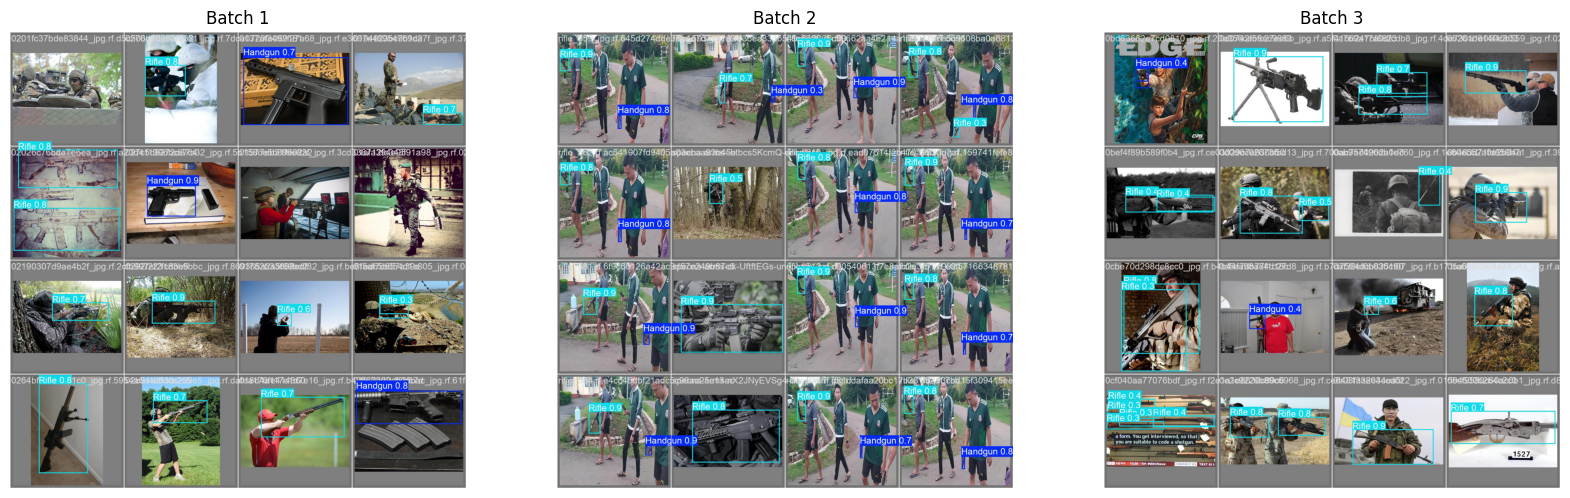

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob

# возьмем часть изображений из валида
val_images = glob.glob(f'{results_dir}/val_batch*.jpg')

print(f"Найдено {len(val_images)} изображений из валида. Отобразим первые три:")

# отобразим первые несколько изображений из валида
plt.figure(figsize=(20, 15))
for i, img_path in enumerate(val_images[:3]):
    img = cv2.imread(img_path)
    # OpenCV загружает в BGR, Matplotlib ожидает RGB (поэтому преобразуем)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Batch {i+1}")
    plt.axis('off')

plt.show()

# Вывод по проделанной работе: анализ показал что модель со стандартными гиперпараметрами работает лучше, создататели этой библиотеки путем экспериментов уже вывели наиболее оптимальную модель, нет смысла что-либо менять. Время обучения моделей практически одинаковое, различалось в несколько минут.